# [IAPR][iapr]: Project - UNO cards segmentation

**Group ID:** 14

**Author 1 (sciper):** Mario Fernández Blanco (412680)  
**Author 2 (sciper):** Mahdi Fourati (313078)   
**Author 3 (sciper):** Antonin Médéric Hudry (341945)

---

### Imports

In [ ]:
from src.utils import *
from src.dataset_creator import *
import cv2
import numpy as np
import os
import os.path as op
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path

In [3]:
REFERENCES_PATH = Path('D:/pattern_analysis/group14_iapr454/project/reference_images')
SEGMENTED_REFERENCE_PATH = Path('D:/pattern_analysis/group14_iapr454/project/segmented_reference_images')

### Introduction

For this project, we decided to use classical methods of segmentation, mainly using fourier descriptors as a mean to classify cards, and morphology to segment them. We created an extended reference dataset, by manually segmenting the reference images, creating rotated versions of these references, creating the contours, curating them manually and using the left over.

From these newly created reference images, we extracted the Fourier descriptors by finding the contours in the image, filtering by size, then interpolating these contours and creating a signal for each filtered contour defined by: $u = x + jy$

With the descriptors, we decided to classify each contour first via a KNN, and then filtering the results further for special cases, and when the contour is too far from any neighbor (OoD).

Three main problem: 
- Holes inside 6, 8, 9 cards (the center numbers not the contours) are detected as zeros, so we had to filter by distance, which isn't a clean way to do it, and can sometimes remove a zero in the prediction, when it was in fact a true label
- skip, zeros and wilds are assimilitad similarly, with zero being prevalent
- 6 and 9 are the 180° spin of each other, so there was no clear way to discriminate both. Attempts were made but unsucessful, so we defaulted to assign everything to 'six'

---

### Data extension

The idea here was to simply manually segment all of the reference images to frame properly each card (note that the blue nine is missing, because one corner was damaged unfortunately and so was disrupting the contour detection):

In [4]:
reference_folder = r"reference_images"

references = []
for path in glob(os.path.join(reference_folder, "*")):
    img = cv2.imread(path, cv2.IMREAD_COLOR_RGB)

    if img is not None:
        references.append(img)

In [5]:
r0 = references[0]

one_two_three = r0[600:2490, 1250:2960]

one   = one_two_three[1240:]
two   = one_two_three[640:1270]
three = one_two_three[10:650]

one_yellow, one_red, one_blue, one_green = one[20:,60:400], one[40:,490:840], one[20:-20,940:1290], one[20:-20,1350:-10]
two_yellow, two_red, two_blue, two_green = two[10:,50:390], two[10:,470:820], two[:-20,900:1250], two[:-20,1290:-10]
three_yellow, three_red, three_blue, three_green = three[20:,20:380], three[20:,430:850], three[20:-10,890:1240], three[:-20,1310:-30]

In [6]:
r1 = references[1]

four_five_six = r1[550:2470,1470:3400]

four = four_five_six[1280:]
five = four_five_six[740:1320]
six  = four_five_six[20:700]

four_yellow, four_red, four_blue, four_green = four[40:-20,160:560], four[30:-10,560:950], four[30:-10,1050:1450], four[60:-10,1530:-10]
five_yellow, five_red, five_blue, five_green = five[20:-20,100:460], five[10:-20,550:910], five[10:,1010:1400], five[10:-20,1500:-40]
six_yellow, six_red, six_blue, six_green = six[90:-20,50:420], six[70:-20,490:890], six[60:-60,1000:1360], six[:-70,1450:-70]

In [7]:
r2 = references[2]

seven_eight_nine = r2[600:2550,1700:3680]

seven = seven_eight_nine[1300:]
eight = seven_eight_nine[720:1300]
nine  = seven_eight_nine[30:680]

wild     = r2[1760:2350,1200:1600]
plus4    = r2[880:1520, 1130:1530]

seven_yellow, seven_red, seven_blue, seven_green = seven[90:-20,170:550], seven[70:-30,630:1000], seven[30:-20,1040:1450], seven[30:-70,1550:-60]
eight_yellow, eight_red, eight_blue, eight_green = eight[40:,110:470], eight[20:-20,560:920], eight[30:-10,1020:1380], eight[10:-20,1530:-90]
nine_yellow, nine_red, nine_blue, nine_green = nine[60:-30,40:400], nine[:-50,520:950], nine[40:,1040:1470], nine[:-60,1550:-10]

In [8]:
r3 = references[3]

plus2s   = r3[1700:2300, 100:1800]
reverses = r3[170:920, 1680:3500]
skips    = r3[880:1630, 1730:3670]
zeros    = r3[1570:2270, 1870:3680]

plus2_yellow, plus2_blue, plus2_red, plus2_green = plus2s[:,:400], plus2s[:,450:850], plus2s[:,850:1250], plus2s[:,1250:]
reverse_yellow, reverse_red, reverse_blue, reverse_green = reverses[150:,:400], reverses[100:-30,470:870], reverses[:650,930:1400], reverses[40:650,1420:]
skip_yellow, skip_red, skip_blue, skip_green = skips[140:,50:480], skips[120:-30,470:880], skips[50:700,890:1350], skips[:650,1430:1890]
zero_yellow, zero_red, zero_blue, zero_green = zeros[50:-10,:430], zeros[40:-50,450:870], zeros[10:630,910:1330], zeros[:620,1350:1790]

In [9]:
image_groups = {
    "zero": [zero_blue, zero_green, zero_red, zero_yellow],
    "one": [one_blue, one_green, one_red, one_yellow],
    "two": [two_blue, two_green, two_red, two_yellow],
    "three": [three_blue, three_green, three_red, three_yellow],
    "four": [four_blue, four_green, four_red, four_yellow],
    "five": [five_blue, five_green, five_red, five_yellow],
    "six-nine": [six_blue, six_green, six_red, six_yellow, nine_green, nine_red, nine_yellow],
    "seven": [seven_blue, seven_green, seven_red, seven_yellow],
    "eight": [eight_blue, eight_green, eight_red, eight_yellow],
    "reverse": [reverse_blue, reverse_green, reverse_red, reverse_yellow],
    "skip": [skip_blue, skip_green, skip_red, skip_yellow],
    "plus": [plus2_blue, plus2_green, plus2_red, plus2_yellow, plus4],
    "wild": [wild],
}


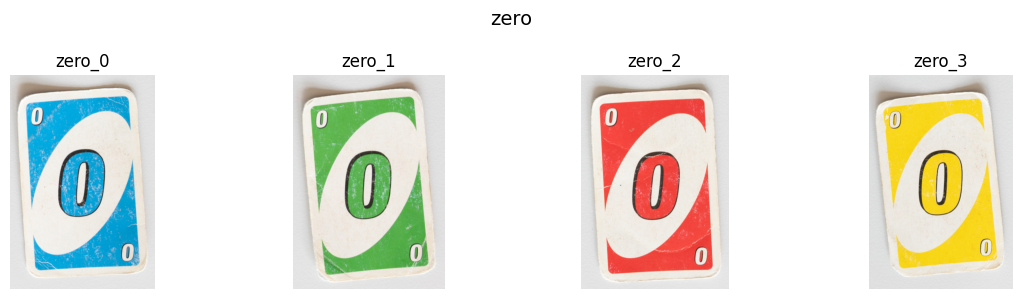

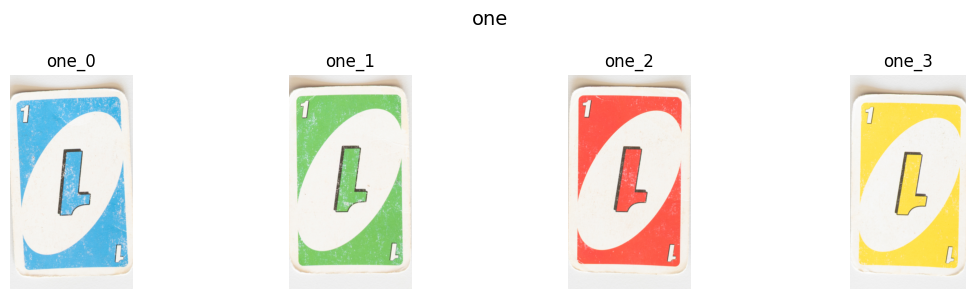

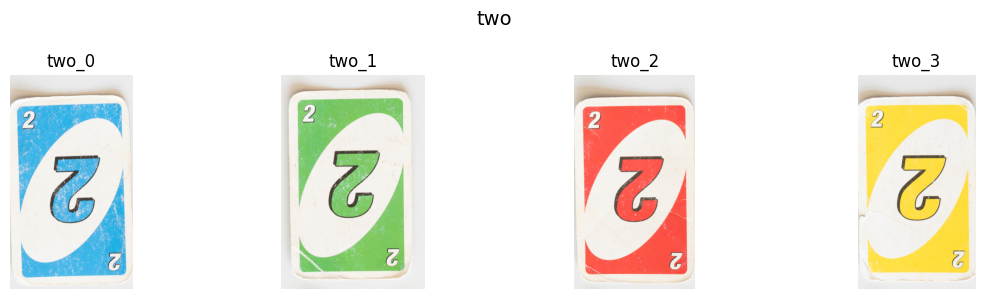

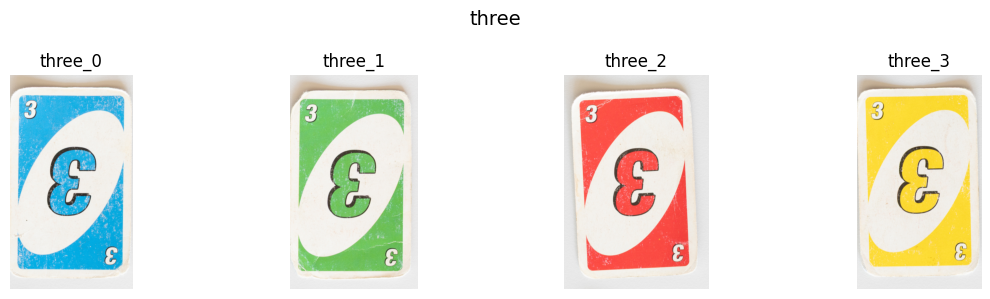

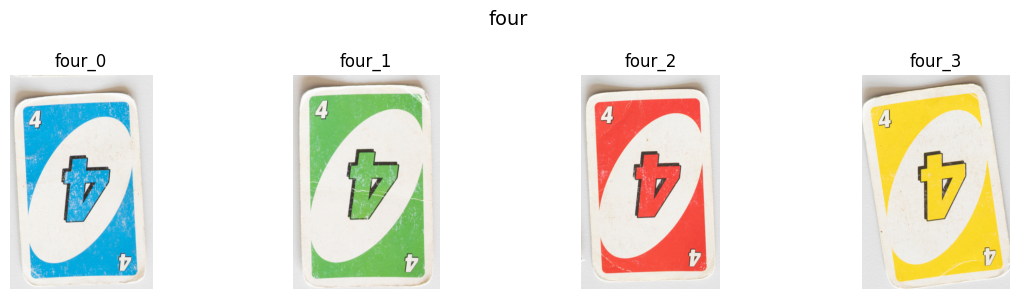

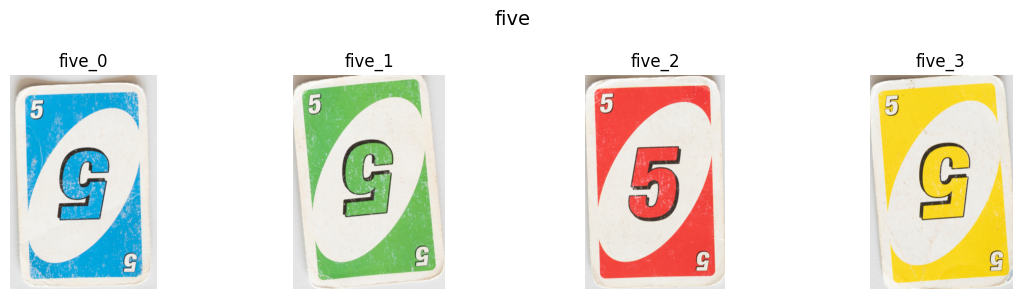

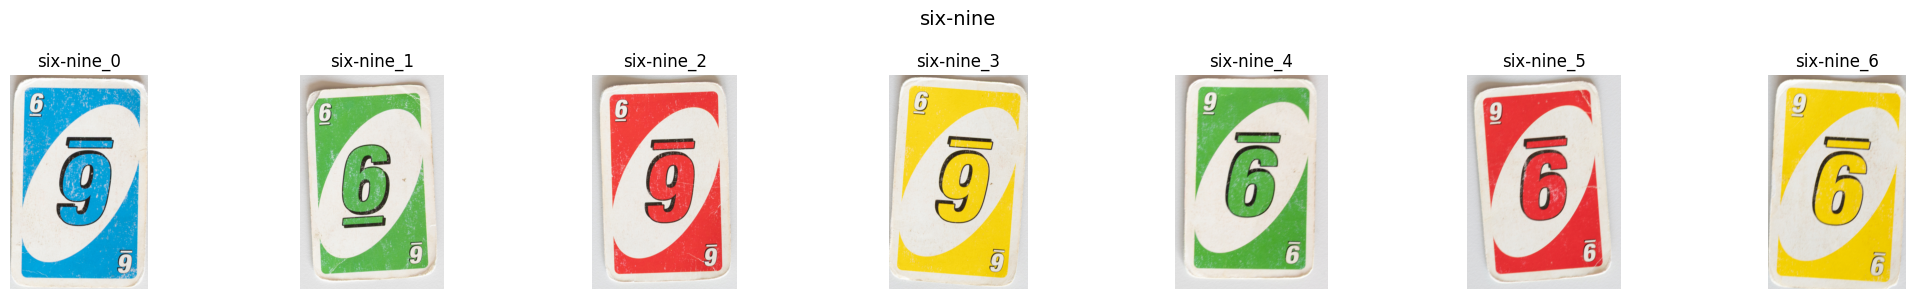

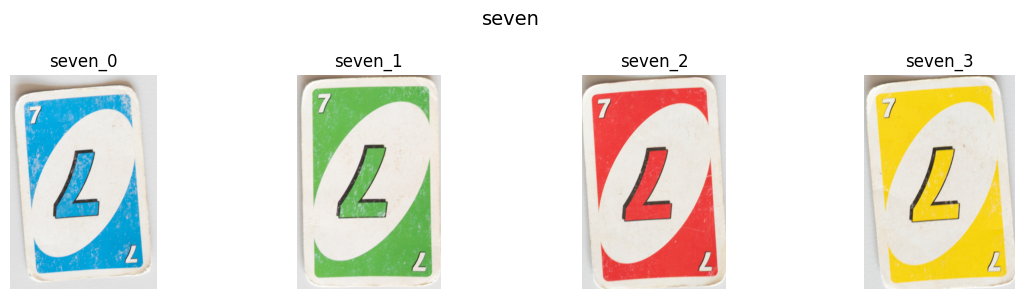

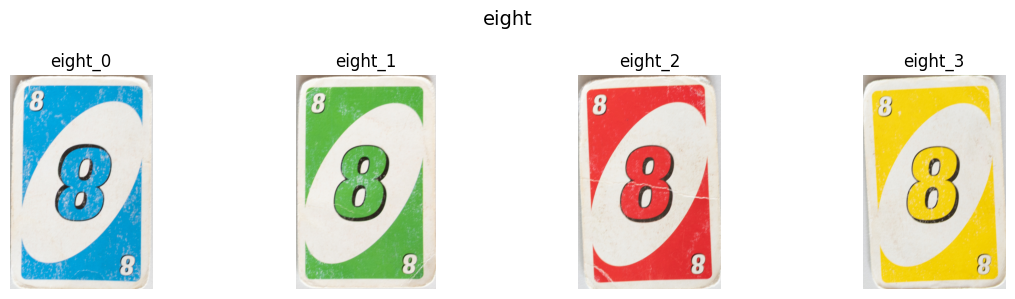

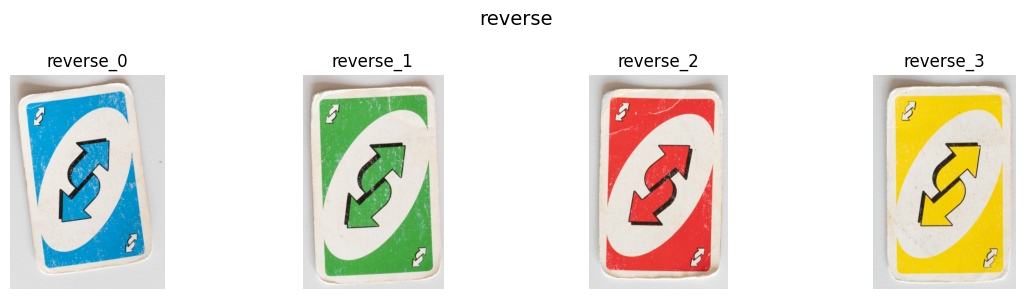

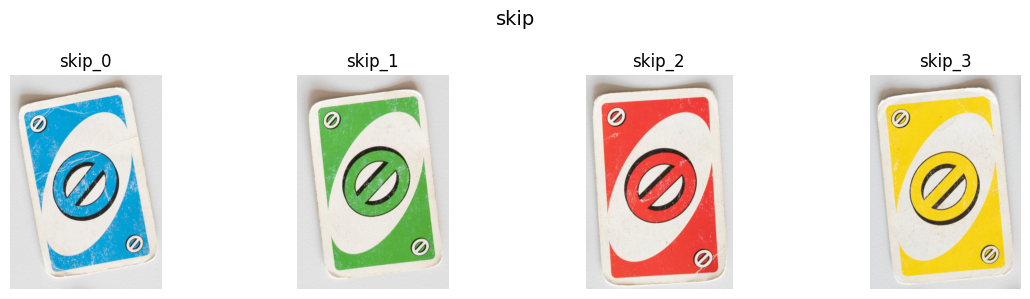

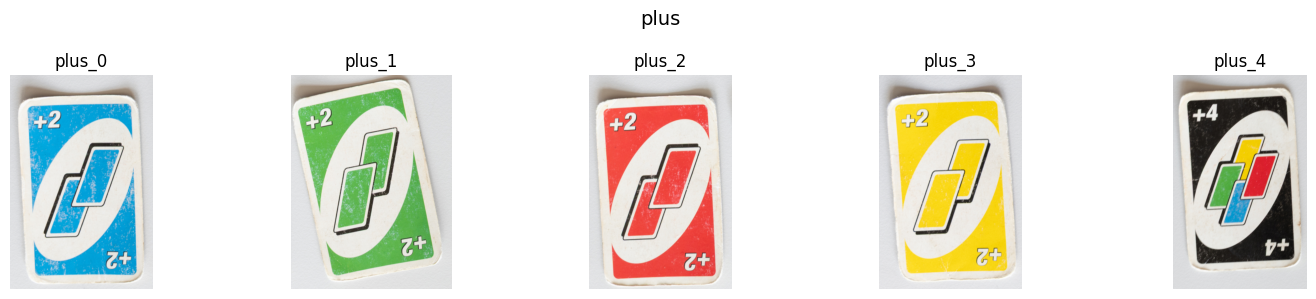

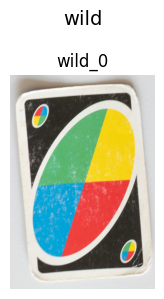

In [10]:
for label, imgs in image_groups.items():

    n = len(imgs)
    fig, axs = plt.subplots(1, n, figsize=(3*n, 3))

    # if only one image (e.g. wild), axs is not a list → fix it
    if n == 1:
        axs = [axs]

    fig.suptitle(label, fontsize=14)

    for i, img in enumerate(imgs):
        axs[i].imshow(img)
        axs[i].set_title(f"{label}_{i}")
        axs[i].axis("off")

    plt.tight_layout()
    plt.show()

---

### Finding cards and contours

The second task is to actually find the cards in the images and get the contours. The simplest way to do it is to apply a threshold on RGB and HSV values.

For the white background image, the task is relatively easy, as we can just filter any pixel that is too white, which keeps most of the card information:

In [11]:
def card_only_filter_blank(img):
    return ((img[:,:,0] < 180) |
            (img[:,:,1] < 180) |
            (img[:,:,2] < 180))

For the background with the leaves, it was a bit more complicated, but we managed to find a good threshold on HSV and RGB without damaging the cards too much:

In [12]:
def card_only_filter_leaf(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    rgb_filtered = apply_rgb_threshold(img, r_range=(200,255), g_range=(200,255), b_range=(200,255)) # see utils
    hsv_filtered = (hsv[:,:,0]<25) | ((hsv[:,:,0]<170)&(hsv[:,:,0]>160))
    return ~(rgb_filtered & hsv_filtered)

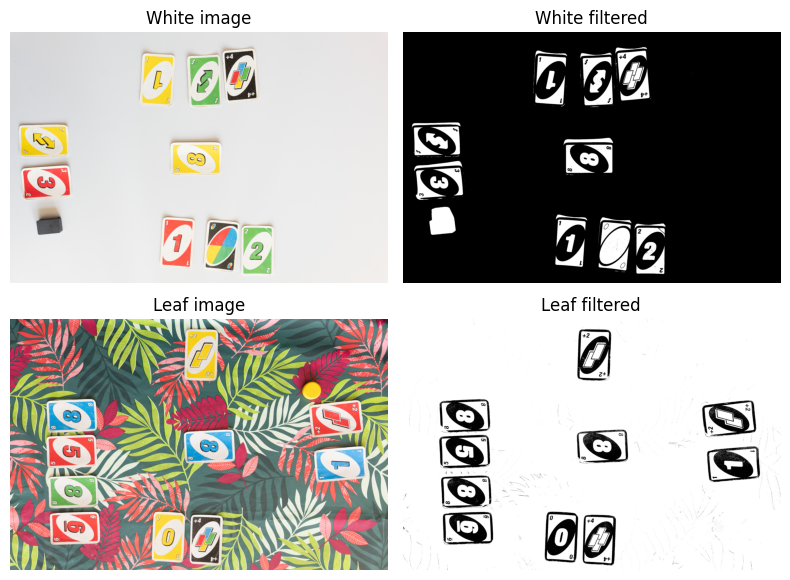

In [13]:
img_white_b = cv2.imread('train_images/L1000773.jpg')
img_leaf_b = cv2.imread('train_images/L1000907.jpg')

img_white = cv2.cvtColor(img_white_b, cv2.COLOR_BGR2RGB)
img_leaf = cv2.cvtColor(img_leaf_b, cv2.COLOR_BGR2RGB)

filtered_white = card_only_filter_blank(img_white_b)
filtered_leaf = card_only_filter_leaf(img_leaf)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0,0].imshow(img_white)
axes[0,0].set_title("White image")

axes[0,1].imshow(filtered_white, cmap='gray')
axes[0,1].set_title("White filtered")

axes[1,0].imshow(img_leaf)
axes[1,0].set_title("Leaf image")

axes[1,1].imshow(filtered_leaf, cmap='gray')
axes[1,1].set_title("Leaf filtered")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

Notice that the filters act a bit differently, but this doesn't matter as long as we can see digits/pictograms.

For the contours, we simply use the function findContours from cv2 with the parameter cv2.RETR_TREE, so that inner contour are made, and so contours can be properly detected on both filters. We know that cards can be stacked on top of each other, so the most reliable way to classify cards is to detect the corner contours, hence we first remove object that are smaller than a minimal size and larger than a maximum size, detect the contours and filter them again by the minimum and maximum area.

In [14]:
def detect_number_contours(gray, min_area=300, max_area=2200):
    """
    Args:
        img: Input RGB image
        min_area: Minimum contour area (filter out noise)
        max_area: Maximum contour area (filter out large regions)
        
    Returns:
        List of valid card contours, edges, dilated image
    """
    
    
    gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
    gray = ~remove_small_objects(~gray.astype(np.uint8), min_size=min_area).astype(np.uint8)

    contours, _ = cv2.findContours(gray, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    valid_contours = []
    for contour in contours:
        area = cv2.contourArea(contour)
        # Filter by area
        if area < min_area or area > max_area:
            continue
        valid_contours.append(contour)
    
    return valid_contours

def plot_contours(image, contours, color=(0, 255, 0), thickness=2):
    """
    Draw contours returned by cv2.findContours.
    """

    if len(image.shape) == 2:
        output = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    else:
        output = image.copy()
        
    cv2.drawContours(output, contours, -1, color, thickness)

    plt.figure(figsize=(8, 8))
    plt.imshow(output)
    plt.axis("off")
    plt.show()

C:\Users\jamaf\AppData\Local\Temp\ipykernel_3272\421864633.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
C:\Users\jamaf\AppData\Local\Temp\ipykernel_3272\421864633.py:14: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = ~remove_small

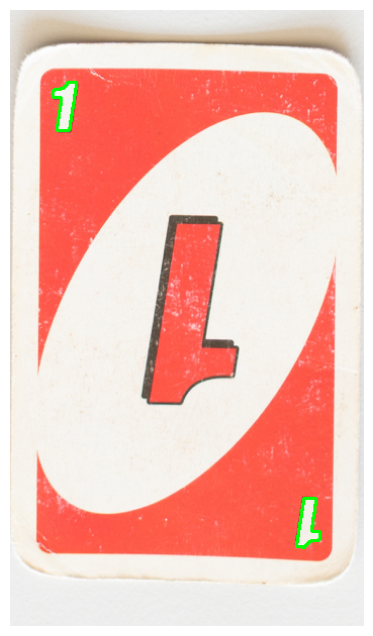

In [15]:
test_img = one_red
filter_img = card_only_filter_blank(test_img)
valid_contours_test = detect_number_contours(filter_img)
_ = plot_contours(test_img, valid_contours_test)

---

### Fourier descriptors

As said in the introduction, the idea is to create a rotated dataset that will serve as a the neighborhood for the subsequent KNN (explained below). Below we create the dataset that is used to create the neighborhood, which consist of all the references we manually cropped:

In [16]:
datasets = {}
all_images = {}
all_contours = {}

for label, imgs in image_groups.items():

    rotated_imgs, contours, descriptors = build_rotated_descriptor_dataset(imgs, label, n_rotations=21, angle_step=9)

    all_images[label] = rotated_imgs
    all_contours[label] = contours

    datasets[label] = np.concatenate(descriptors, axis=0)

c:\Users\jamaf\Documents\Universidad\8 semestre (EPFL)\IAPR\group14\group14_iapr454\project\utils.py:338: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
c:\Users\jamaf\Documents\Universidad\8 semestre (EPFL)\IAPR\group14\group14_iapr454\project\utils.py:339: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value

Then we just applied what was done in lab 2 of this course on the contours of the corner pictograms, which includes interpolation and descriptor correction. Note that we made the descriptors invariant to rotation and position, but not to scaling as every card should have the same size in theory:

In [17]:
def fourier_descriptors(contours, n_samples=100, interpolation=True):
    """
    Compute translation and rotation invariant Fourier descriptors.
    
    Parameters
    ----------
    contours : list of (K,2) arrays
    n_samples : int
    interpolation : bool

    Returns
    -------
    descriptors : (N, n_samples-1)
        Translation + rotation invariant descriptors.

    centers : (N, 2)
        Contour centroids.

    rotations : (N,)
        Dominant contour orientation in radians.
    """

    descriptors = []
    centers = []
    rotations = []

    for contour in contours:

        contour = np.asarray(contour.squeeze(), dtype=np.float64)
        
        d = np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1))
        t = np.concatenate([[0], np.cumsum(d)])

        t_new = np.linspace(0, t[-1], n_samples)
        x = np.interp(t_new, t, contour[:, 0])
        y = np.interp(t_new, t, contour[:, 1])

        contour = np.stack([x, y], axis=1)
        
        center = contour.mean(axis=0)
        centers.append(center)

        z = contour[:, 0] + 1j * contour[:, 1]
        fd = np.fft.fft(z)
        fd[0] = 0

        rotation = np.angle(fd[1])
        rotations.append(rotation)
        fd *= np.exp(-1j * rotation)
        descriptors.append(np.abs(fd[1:]))

    return (
        np.array(descriptors),
        np.array(centers),
        np.array(rotations)
    )

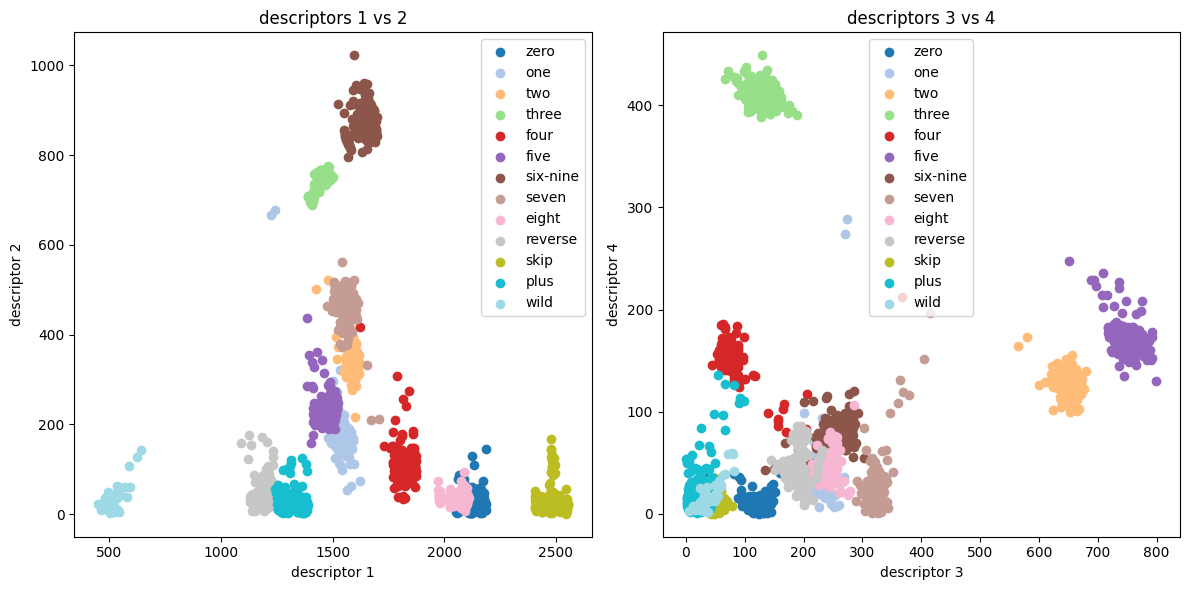

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

colors = plt.cm.tab20(np.linspace(0, 1, len(datasets)))

for (label, data), color in zip(datasets.items(), colors):

    axes[0].scatter(
        data[:, 0],
        data[:, 1],
        label=label,
        color=color
    )

    axes[1].scatter(
        data[:, 2],
        data[:, 3],
        label=label,
        color=color
    )

axes[0].set_title("descriptors 1 vs 2")
axes[1].set_title("descriptors 3 vs 4")
axes[0].set_xlabel('descriptor 1')
axes[0].set_ylabel('descriptor 2')
axes[1].set_xlabel('descriptor 3')
axes[1].set_ylabel('descriptor 4')

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

As you can see, the cloud of point is already very separable with only four descriptors. In the dataset, we are using 100 fourier descriptors, so it should already give a good classifier.

---

### Cropping contour and finding colors

Of course, until now we have only focused on classifying the simbol of the card using the contours. However, we also have to take into acount the color of the card.

For this task, we decided to extract and normalize a crop of the image around each contour we detected, and from that, extract the color of the card based on the RGB values of it.

The first part of this step is to find a rectangle that contains the contour we want to analyse, and for that we use cv2. Furthermore, since we want to find the color of the card, and the contour contains only the white number, we extend this rectangle to include more information from the card.

For this step we use the following code.

In [19]:
"""
rect = cv2.minAreaRect(contour)
box = cv2.boxPoints(rect)

# Calculate center of the bounding box
center = box.mean(axis=0)

# Apply extension by moving each corner away from center
if extension > 0:
    for i in range(4):
        direction = box[i] - center
        norm = np.linalg.norm(direction)
        if norm > 0:
            box[i] = box[i] + (direction / norm) * extension

"""

'\nrect = cv2.minAreaRect(contour)\nbox = cv2.boxPoints(rect)\n\n# Calculate center of the bounding box\ncenter = box.mean(axis=0)\n\n# Apply extension by moving each corner away from center\nif extension > 0:\n    for i in range(4):\n        direction = box[i] - center\n        norm = np.linalg.norm(direction)\n        if norm > 0:\n            box[i] = box[i] + (direction / norm) * extension\n\n'

Once we have this rectangle (identified by the 4 points on its corners) we compute the distances between these points to get their adjacency matrix, so that we can determine where does each point belong. When we find all point that are conected to each other, we use the shoelace formula to make sure that we are not mirroring the contour, and then relate each of the corners we have ordered with their corresponding corner of the normalize rectangle.

We finally get the transformation matrix with cv2 and use it on the cropped image to get the area around the simbol.

C:\Users\jamaf\AppData\Local\Temp\ipykernel_3272\421864633.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
C:\Users\jamaf\AppData\Local\Temp\ipykernel_3272\421864633.py:14: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = ~remove_small

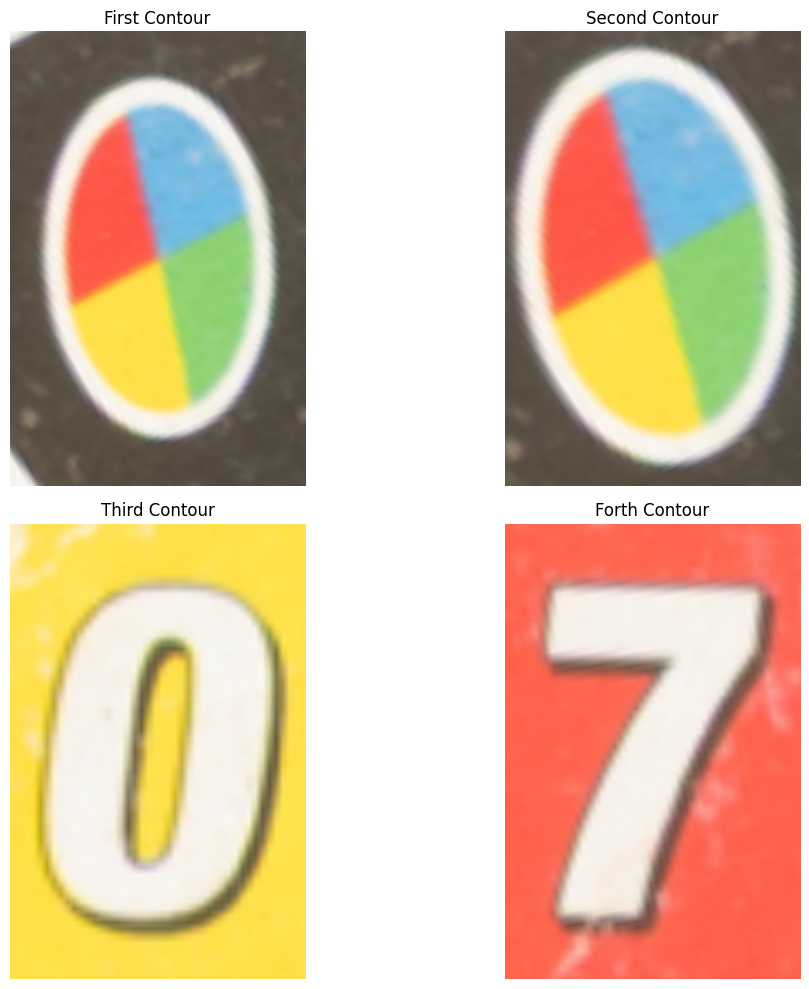

In [20]:
img = cv2.imread('train_images/L1000775.jpg')
gray = card_only_filter_blank(img)

valid_contours = detect_number_contours(gray)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

if len(valid_contours) > 4:
    normalized_0 = extract_and_normalize_card(img, valid_contours[0], extension=10)
    normalized_1 = extract_and_normalize_card(img, valid_contours[1], extension=10)
    normalized_2 = extract_and_normalize_card(img, valid_contours[2], extension=10)
    normalized_3 = extract_and_normalize_card(img, valid_contours[3], extension=10)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].imshow(normalized_0)
    axes[0, 0].set_title("First Contour")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(normalized_1)
    axes[0, 1].set_title(f"Second Contour")
    axes[0, 1].axis('off')

    axes[1, 0].imshow(normalized_2)
    axes[1, 0].set_title("Third Contour")
    axes[1, 0].axis('off')

    axes[1, 1].imshow(normalized_3)
    axes[1, 1].set_title(f"Forth Contour")
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

Then, for the classification of the color itself, we check the values of the mean for each RGB channel, and based on certain threshold he select the corresponding label.

In [21]:
def classify_card_color(img_rgb):
    """
    Args:
        img_rgb: RGB normalized card image

    Returns:
        'r', 'y', 'g', 'b', 'black', or None
    """

    img = img_rgb.astype(np.uint8)

    valid_mask = card_only_filter_blank(img)
    valid_pixels = img[valid_mask]

    if len(valid_pixels) < 50:
        return None

    mean_rgb = valid_pixels.mean(axis=0)

    if mean_rgb.mean() < 60:
        return "black"

    dominant = np.argmax(mean_rgb)

    if dominant == 0:
        if abs(mean_rgb[0] - mean_rgb[1]) < 40:
            return "y"
        return "r"
    elif dominant == 1:
        return "g"
    elif dominant == 2:
        return "b"

    return None

print("Color of contour 2:" , classify_card_color(normalized_2))
print("Color of contour 3:" , classify_card_color(normalized_3))

Color of contour 2: y
Color of contour 3: r


----

### KNN Classifier

As seen before, we extended the dataset to get only cropped reference images, as well as rotated version of these reference. This allowed us to get a pretty large data cloud. What is good with UNO cards is that the shape of the contours shouldn't change much (apart from slight camera angle variation and scale), which means that every contour we detect should be relatively close to the cloud we generated.

Our idea is to use this fourier descriptors cloud as a reference, and classify contours based on their distance to these points. This is basically the definition of a KNN classifier. Since our data point types are inhomogenous in number (due to data curation and number of available samples (e.g. 4 for colored card and one for wild and draw 4)), the fairest and also what was found more effective is using a single nearest neighbor. This usually leads to overfitting, but again, the shape of our contour shouldn't differ by much between cards, so overfitting is not as relevant here. However, we can have detected contours that correspond to none of the card, due to noise or the holes inside some numbers. In this case, we apply a rejection threshold based on distance. So a point that is too far from everything should be rejected.

We found that a rejection threshold of ~8.5 is sufficient. If you want more details, check the notebook reference_segmentation.

Below is the code for the classifier and a test on one image:

In [22]:
class FourierDiscriminator:

    def __init__(
        self,
        n_neighbors=3,
        rejection_threshold=2.0
    ):

        self.scaler = StandardScaler()

        self.knn = KNeighborsClassifier(
            n_neighbors=n_neighbors
        )

        self.rejection_threshold = rejection_threshold

    def fit(
        self,
        datasets,
        test_size=0.2,
        random_state=42,
        verbose = False
    ):

        X, y = build_classifier_dataset(datasets)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            stratify=y,
            random_state=random_state
        )
        X_train = self.scaler.fit_transform(X_train)
        X_test = self.scaler.transform(X_test)

        self.knn.fit(X_train, y_train)

        y_pred = self.knn.predict(X_test)
        if verbose:
            print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
            print(f"Macro F1 : {f1_score(y_test, y_pred, average='macro'):.4f}\n")
            print(classification_report(y_test, y_pred))

    def predict(self, descriptor):

        descriptor = np.asarray(descriptor).reshape(1, -1)
        descriptor = self.scaler.transform(descriptor)

        distances, _ = self.knn.kneighbors(descriptor)
        mean_distance = distances.mean()

        if mean_distance > self.rejection_threshold:
            return "None", mean_distance

        prediction = self.knn.predict(descriptor)[0]

        return prediction, mean_distance

In [23]:
classifier = FourierDiscriminator(n_neighbors=1, rejection_threshold=8.5)
classifier.fit(datasets)

In [24]:
img_test = cv2.imread('train_images/L1000772.jpg', cv2.IMREAD_COLOR_RGB)
contours = detect_number_contours(card_only_filter_blank(img_test).astype(np.uint8))
descriptors, centers, angles = fourier_descriptors(contours)

card_types = []
for idx, descriptor in enumerate(descriptors):

    descriptor = np.asarray(descriptor).flatten()
    card_type, dist = classifier.predict(descriptor)
    card_types.append(card_type)
print(card_types)

C:\Users\jamaf\AppData\Local\Temp\ipykernel_3272\421864633.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
C:\Users\jamaf\AppData\Local\Temp\ipykernel_3272\421864633.py:14: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = ~remove_small

[np.str_('eight'), np.str_('six-nine'), np.str_('zero'), np.str_('eight'), np.str_('zero'), np.str_('three'), np.str_('eight'), np.str_('six-nine'), np.str_('three'), 'None', np.str_('seven'), np.str_('seven'), np.str_('zero'), 'None', 'None', 'None', np.str_('zero'), np.str_('six-nine'), np.str_('six-nine'), np.str_('plus'), np.str_('two'), np.str_('two'), np.str_('plus'), np.str_('zero'), np.str_('zero'), 'None', 'None', np.str_('three'), 'None', np.str_('six-nine'), np.str_('zero'), np.str_('six-nine'), 'None', np.str_('zero'), np.str_('six-nine'), np.str_('two'), np.str_('six-nine')]


You might have noticed that there is too many outputs from the classifier, and also repeats. This is because, there is two contours per card, and some contours bypass the classification and area filtering. We apply correction that will be explained in the subsequent sections.

---

### Assigning cards to players and center

We can easily assign card to players by separating the image in five regions, for p1, p2, p3, p4 and center. We first load the training images:

In [25]:
project_root = Path.cwd()
folder_train = project_root / "train_images"

images_train = []
for path in glob(os.path.join(folder_train, "*")):
    img = cv2.imread(path)

    if img is not None:
        images_train.append(img)

Then we segregate and filter the white backgrounds, as an easy way to see bondaries:

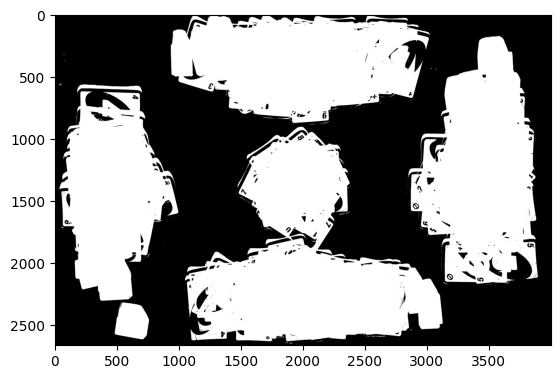

In [26]:
white_b_train = [img for img in images_train if np.mean(img)>180]
segmented_images_train = np.array([card_only_filter_blank(img)
                          for img in white_b_train])
sum_train = np.sum(segmented_images_train, axis=0)
normalized_sum_train = (sum_train*255)/np.max(sum_train)
border_train = sum_train>0
plt.imshow(border_train, cmap="gray")

As you can see we can clearly delimitate the player area, if we consider that they will stay consistent for all images:

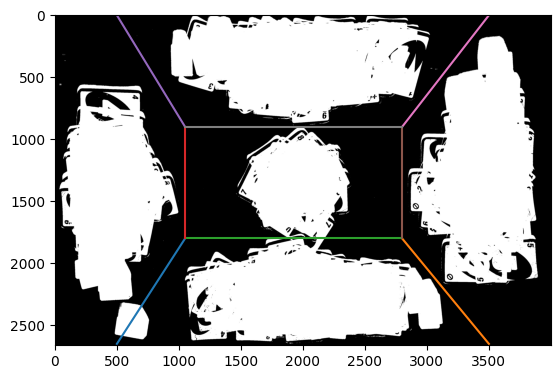

In [27]:
plt.imshow(border_train, cmap="gray")
plt.plot([500,1050],[2650,1800])
plt.plot([3500,2800],[2650,1800])
plt.plot([1050,2800], [1800,1800])
plt.plot([1050,1050],[1800,900])
plt.plot([500,1050],[0,900])
plt.plot([2800,2800],[1800,900])
plt.plot([2800,3500],[900,0])
plt.plot([1050,2800], [900,900])

This allows us to manually segment the image with the function below:

In [28]:
def assign_card2player(center):

    top_l = lambda x: ((1800-2662)/(1050-500))*(x-500) + 2662
    top_r = lambda x: ((1800-2662)/(2800-3500))*(x-3500) + 2662
    bot_l = lambda x: ((900-0)/(1050-500))*(x-500)
    bot_r = lambda x: ((0-900)/(3500-2800))*(x-2800) + 900
    
    if center[1] < 900 and center[1] < bot_l(center[0]) and center[1] < bot_r(center[0]):
        return 'p3'
    elif center[0] < 1050 and center[1] > bot_l(center[0]) and center[1] < top_l(center[0]):
        return 'p4'
    elif center[1] > 1800 and center[1] > top_l(center[0]) and center[1] > top_r(center[0]):
        return 'p1'
    elif center[0] > 2800 and center[1] > bot_r(center[0]) and center[1] < top_r(center[0]):
        return 'p2'
    else:
        return 'center'

---

### Correcting assignment

We first designed a function that removes duplicate detections caused by multiple contours detecting the same UNO symbol.

Two predictions are considered duplicates if they have:
- the same predicted class
- the same color
- centers closer than `pair_distance_target` (530 px)

When duplicates are found, only the first prediction is kept.

This mainly removes:
- inner + outer contour detections
- fragmented contour duplicates
- multiple detections of the same card symbol

In [29]:
def deduplicate_predictions(
    predictions,
    pair_distance_target=530
):
    """
    Keep only one prediction when:
    - same class
    - same color
    - same angle
    - AND centers are either:
        * extremely close (duplicate)
        * OR separated by ~480 +/- margin
    """

    kept = []

    for pred in predictions:

        keep = True

        center_a = np.array(pred["center"])
        angle_a = pred["angle"]
        class_a = pred["class"]
        color_a = pred["color"]

        for existing in kept:

            center_b = np.array(existing["center"])
            angle_b = existing["angle"]
            class_b = existing["class"]
            color_b = existing["color"]

            same_class = class_a == class_b
            same_color = color_a == color_b

            angle_diff = abs(angle_a - angle_b)
            angle_diff = min(angle_diff, 360 - angle_diff)

            #deprecated (does not work well)
            #same_angle = angle_diff < angle_thresh
            same_angle = True

            dist = np.linalg.norm(center_a - center_b)

            close_duplicate = (
                dist < pair_distance_target
            )
            
            if (
                same_class
                and same_color
                and same_angle
                and close_duplicate
            ):
                keep = False
                break

        if keep:
            kept.append(pred)

    return kept

Then we also designed a function that detects UNO card symbols using the previous function and applies post-processing corrections as well as the removal of duplicates. The full pipeline is the following:
- applies scene-dependent filtering (white background vs leaf background)
- extracts symbol contours
- computes Fourier descriptors
- predicts symbol class with KNN classifier
- extracts card color and player ownership
- fixes `wild ↔ zero` confusion using card color
- removes invalid black card detections
- merges `plus + two/four → plus2/plus4`
- removes false `zero` detections near `six/eight/nine` of the same color (as they could lead to a zero detected in the center pictogram)
- removes duplicate detections (`deduplicate_predictions`)

Returns a cleaned list of detected cards with:
- class
- color
- player
- center position
- contour angle
- classifier distance

The other parameters returned other than class, color and player are mainly for debugging

In [30]:
def classify_image(
    img,
    classifier,
    pair_distance_target=530,
    distance_threshold_plus=50
):
    
    mean_value = img.mean()

    if mean_value > 200:
        gray = card_only_filter_blank(img)
    else:
        gray = card_only_filter_leaf(img)
    contours = detect_number_contours(gray)
    descriptors, centers, angles = fourier_descriptors(contours)

    raw_predictions = []

    for idx, descriptor in enumerate(descriptors):

        descriptor = np.asarray(descriptor).flatten()
        card_type, dist = classifier.predict(descriptor)
        if card_type == "None":
            continue

        normalized_card = extract_and_normalize_card(
            img,
            contours[idx],
            extension=10
        )

        if card_type == "six-nine":
            # TODO: proper discrimination
            card_type = "six"

        color = classify_card_color(normalized_card)
        player = assign_card2player(centers[idx])

        if player is None:
            continue
        if color == "black" and card_type == 'zero':
            card_type = 'wild'
        if color != "black" and card_type == 'wild':
            card_type = 'zero'
        if color == "black" and card_type not in ["wild", "plus"]:
            continue

        raw_predictions.append({
            "class": card_type,
            "color": color,
            "mean_color": cv2.mean(normalized_card)[:3],
            "player": player,
            "center": centers[idx],
            "angle": angles[idx],
            "distance": dist
        })

    plus_cards = [
        p for p in raw_predictions
        if p["class"] == "plus"
    ]

    non_plus = [
        p for p in raw_predictions
        if p["class"] != "plus"
    ]

    final_predictions = []

    used_non_plus = set()

    for plus in plus_cards:

        plus_center = np.array(plus["center"])

        nearest = None
        nearest_dist = float("inf")

        nearest_type = None

        for i, p in enumerate(non_plus):

            if i in used_non_plus:
                continue
            if p["class"] not in ["two", "four"]:
                continue

            d = np.linalg.norm(
                np.array(p["center"]) - plus_center
            )
            if d < nearest_dist and d < distance_threshold_plus:
                nearest_dist = d
                nearest = i
                nearest_type = p["class"]

        plus_fixed = dict(plus)
        if nearest_type == "four":
            plus_fixed["class"] = "plus4"
        elif nearest_type == "two":
            plus_fixed["class"] = "plus2"

        #default
        else:
            plus_fixed["class"] = "plus2"

        final_predictions.append(plus_fixed)
        if nearest is not None:
            used_non_plus.add(nearest)

    for i, p in enumerate(non_plus):
        if i in used_non_plus:
            continue
        final_predictions.append(p)

    filtered_predictions = []
    for i, p in enumerate(final_predictions):

        if p["class"] != "zero":
            continue

        zero_center = np.array(p["center"])

        remove_zero = False

        for q in final_predictions:

            if q["class"] not in ["six", "eight", "nine"]:
                continue

            if q["color"] != p["color"]:
                continue

            d = np.linalg.norm(
                zero_center - np.array(q["center"])
            )

            if d < (2/3)*pair_distance_target:
                remove_zero = True
                break

        if not remove_zero:
            filtered_predictions.append(p)

    # keep everything that is NOT zero (including 6/8/9 always)
    for p in final_predictions:
        if p["class"] != "zero":
            filtered_predictions.append(p)

    final_predictions = filtered_predictions
    
    final_predictions = deduplicate_predictions(
        final_predictions,
        pair_distance_target=pair_distance_target
    )

    return final_predictions

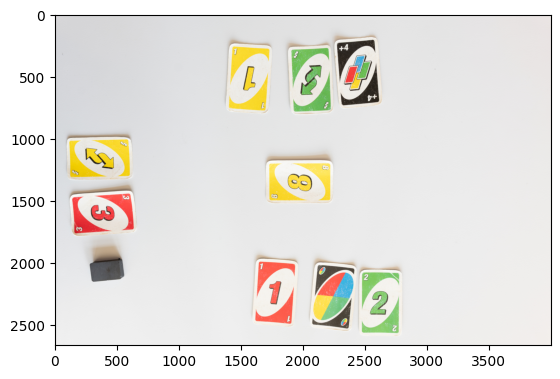

In [31]:
plt.imshow(img_white)

In [32]:
classify_image(img_white, classifier=classifier)

C:\Users\jamaf\AppData\Local\Temp\ipykernel_3272\421864633.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
C:\Users\jamaf\AppData\Local\Temp\ipykernel_3272\421864633.py:14: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = ~remove_small

[{'class': 'zero',
  'color': 'y',
  'mean_color': (158.40298412698414, 152.63732804232805, 124.86579894179894),
  'player': 'p1',
  'center': array([2325.80121527, 2476.94615796]),
  'angle': np.float64(-0.6089952094539746),
  'distance': np.float64(7.487705769945638)},
 {'class': 'plus2',
  'color': 'black',
  'mean_color': (111.71530158730158, 104.63254497354498, 96.71767724867725),
  'player': 'p3',
  'center': array([2571.45085791,  664.084211  ]),
  'angle': np.float64(-1.6987557800944706),
  'distance': np.float64(5.099349363736867)},
 {'class': np.str_('skip'),
  'color': 'y',
  'mean_color': (139.57754497354497, 133.15491534391535, 109.6968783068783),
  'player': 'p1',
  'center': array([2326.02070265, 2476.49680221]),
  'angle': np.float64(-1.433356383629738),
  'distance': np.float64(5.4798485299414885)},
 {'class': np.str_('two'),
  'color': 'g',
  'mean_color': (170.3372275132275, 207.155708994709, 157.96623809523808),
  'player': 'p1',
  'center': array([2732.13837721, 25

---
### Finding the active player

As well as for the rest of this project, we decided to use classical methods for finding the token that signals who the active player is, as we believe this kind of procedures are more explainable and visually understandable.

For this task, we assumed that there were only two types of background: Completely white and the noisy leave pattern. With this in mind, we curated a color filtering to keep only the regions of the images that could possibly be the token we were looking for.

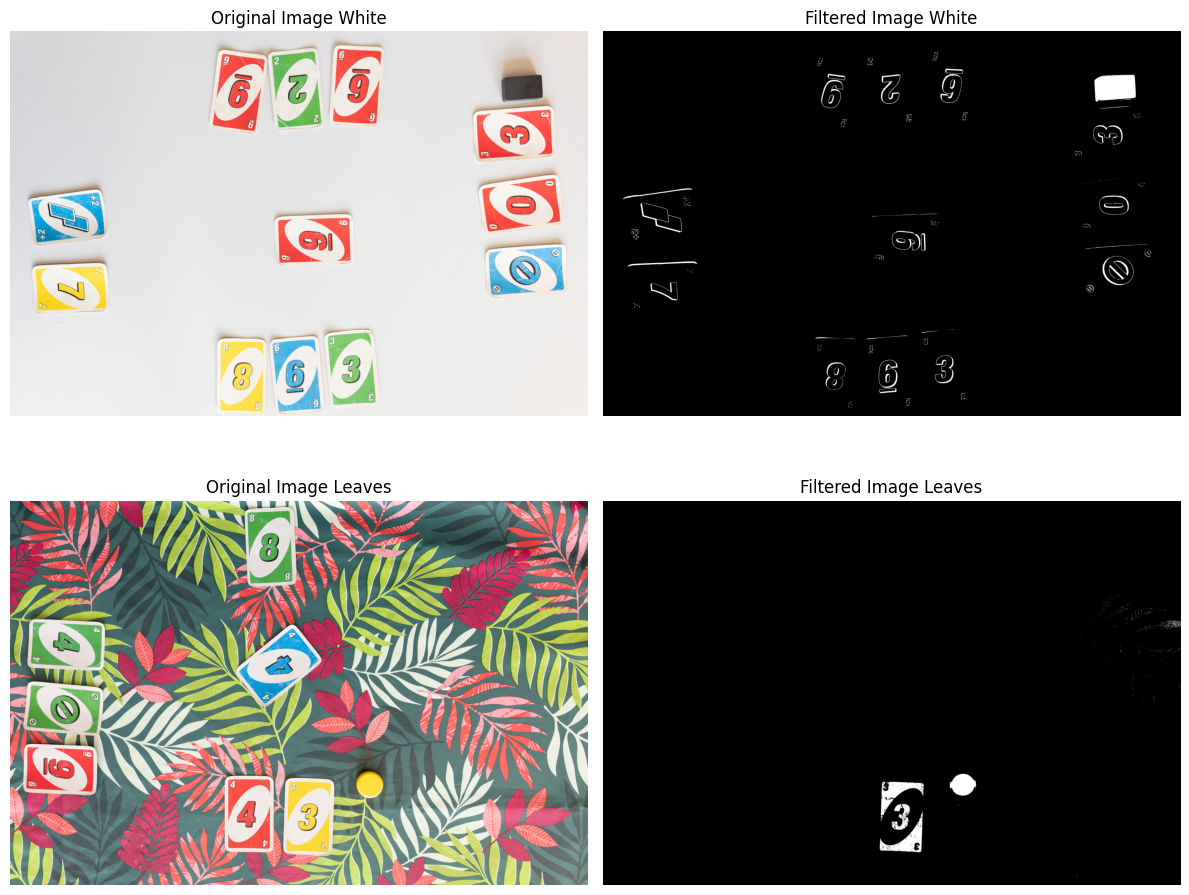

In [33]:
img = cv2.imread('train_images/L1000772.jpg', cv2.IMREAD_COLOR_RGB)
img_leaves = cv2.imread('train_images/L1000909.jpg', cv2.IMREAD_COLOR_RGB)

img_filter_white = apply_rgb_threshold(img, (0,150), (0,150), (0,150))

img_filter_leaves = apply_rgb_threshold(img_leaves, (200,255), (200,255), (0,80))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img)
axes[0, 0].set_title("Original Image White")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_filter_white, cmap='gray')
axes[0, 1].set_title(f"Filtered Image White")
axes[0, 1].axis('off')

axes[1, 0].imshow(img_leaves)
axes[1, 0].set_title("Original Image Leaves")
axes[1, 0].axis('off')

axes[1, 1].imshow(img_filter_leaves, cmap='gray')
axes[1, 1].set_title(f"Filtered Image Leaves")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Once we had filtered the images, we cropped them into the different regions for each player and applied an opening to keep only the token and eliminate the rest of artifacts.

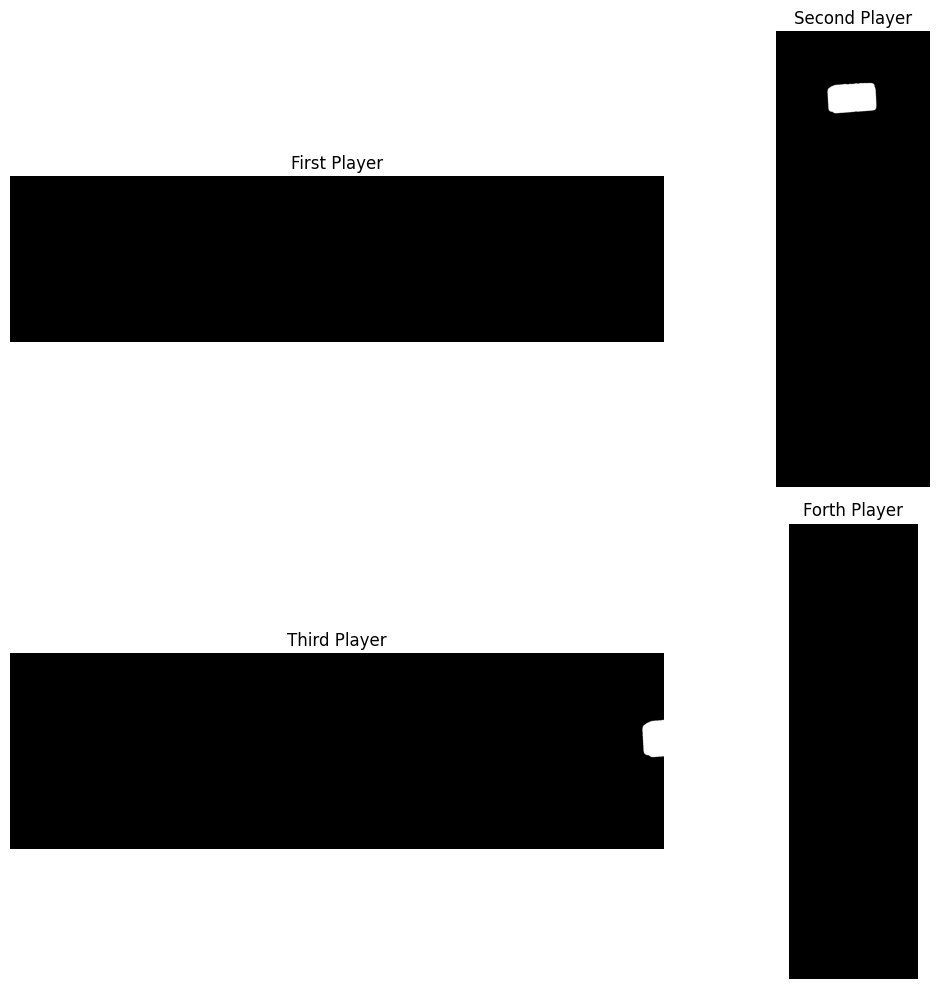

In [34]:
img_1 = apply_opening(img_filter_white[1900:,500:3500], 20)
img_2 = apply_opening(img_filter_white[:,3100:], 20)
img_3 = apply_opening(img_filter_white[:900,500:3500], 20)
img_4 = apply_opening(img_filter_white[:,:750], 20)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_1, cmap='gray')
axes[0, 0].set_title("First Player")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_2, cmap='gray')
axes[0, 1].set_title(f"Second Player")
axes[0, 1].axis('off')

axes[1, 0].imshow(img_3, cmap='gray')
axes[1, 0].set_title("Third Player")
axes[1, 0].axis('off')

axes[1, 1].imshow(img_4, cmap='gray')
axes[1, 1].set_title(f"Forth Player")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

As the crops overlap, it is posible that more than one end up having part of the token, so to determine who the starting player is, we count the number of pixels of token in each crop, and the one with the most is chosen as the active player.

Of course, this crops are predetermined, and while they usually cover most of the space a player takes on the table, it is posible that the token could be outside of this part of the image, leading to an error, but as it works for the great majority of cases, we believe that this solution is good enough without having to overcomplicate it.

The whole function ends up like this: 

In [35]:
def find_active_player(img):
    mean_value = img.mean()
    
    n = []

    if mean_value > 200:
        img_filter = apply_rgb_threshold(img, (0,150), (0,150), (0,150))

    else:
        img_filter = apply_rgb_threshold(img, (200,255), (200,255), (0,80))
    img_1 = apply_opening(img_filter[1900:,500:3500], 20)
    img_2 = apply_opening(img_filter[:,3100:], 20)
    img_3 = apply_opening(img_filter[:900,500:3500], 20)
    img_4 = apply_opening(img_filter[:,:750], 20)

    n.append(sum(img_1[img_1 == True]))
    n.append(sum(img_2[img_2 == True]))
    n.append(sum(img_3[img_3 == True]))
    n.append(sum(img_4[img_4 == True]))

    player = np.argmax(n) + 1

    return "p"+str(player)

---
## Main failure points

As it can be imagined, classical methods cannot completely solve a task like this, at least with the tools we have used. There are a series of issues that cannot be avoided and lower the overall performance of our pipeline.

* Six and nine discrimination: Since we are using the rotation-invariant contours of the numbers as a mean to classify them, the features we obtain for the number 6 and the number 9 are nearly identical. We tried implementing a function to difference them based on the bar they have, but it was too inconsistent, so we ended up just describing all of them as 6, causing a decrease in accuracy.

* Holes detected as valid cards: when the center of certain cards is visible, our pipeline can detect the holes in numbers such as 0, 6, 8, or 9 as independent contours, and this contours can end up being classified as 0.

C:\Users\jamaf\AppData\Local\Temp\ipykernel_3272\421864633.py:13: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)
C:\Users\jamaf\AppData\Local\Temp\ipykernel_3272\421864633.py:14: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  gray = ~remove_small

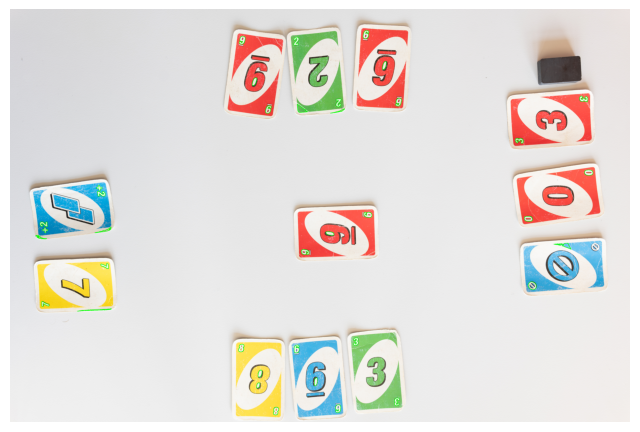

In [36]:
test_img = img
filter_img = card_only_filter_blank(test_img)
valid_contours_test = detect_number_contours(filter_img)
_ = plot_contours(test_img, valid_contours_test)

* Light variation: as our segmentation is based on RGB and HSV filtering, it can be highly dependent on changes in the light of the scene, leading to our classification working well in some images and quite poorly on others where the filters are not as good.